# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import pydicom
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [ ]:
#seed used for random
seed = 42
torch.manual_seed(seed)

# Loading measurement data

In [ ]:
#read csv
df = pd.read_csv("../data/measurements.csv")

print(df.columns)

#drop unnecessary columns
df.drop(columns = ["Student Name", "Notes", "Unnamed: 23", "Unnamed: 24", "Unnamed: 25", "Unnamed: 26"], inplace = True)

print(df.columns)

print(len(df.columns.values))

In [ ]:
#get rid of images with na (only temporary for convenience)
df = df.dropna()

# Load image data (augmentation, datasets, and dataloaders)

In [ ]:
#image directory
img_dir = "../data/box_images"

#train test split
train_test_split = 0.8

#batch size
train_batch_size = 128
test_batch_size = 8

#pixels per mm conversion (known)
pix_per_mm = 2400 / 408

#training scale factor
img_scale_factor = 0.1

#image size (pix)
img_width = int(2400 * img_scale_factor)
img_height = int(1920 * img_scale_factor)

In [ ]:
#data augmentation settings
## rotation
rot_int = 90
rot_st = 0
rot_en = 360 - rot_int

##down scale
scale_int = 0.1
scale_st = 0.5
scale_en = 0.6 #TODO can change this, 0.6 was chosen so no matter what rotation, no part of image is cut off

In [ ]:
# #####FIXME STRICTLY TESTING FIXME#####
# rot_int = 30
# rot_st = 0
# rot_en = 0

# scale_int = 0.1
# scale_st = 1
# scale_en = 1

In [ ]:
#class for each data point: image path, flip (if asking for left side of image), rotation, scale, true values for measurements
class DataPoint:
    def __init__(self, img_dir, img_file, img_flip, df, img_width, img_height, aug_rot = 0, aug_scale = 1):
        self.img_path = img_dir + '/' + img_file
        self.img_flip = img_flip
        self.img_width = img_width
        self.img_height = img_height
        self.aug_rot = aug_rot
        self.aug_scale = aug_scale
        self.y = torch.from_numpy(df.loc[df['ID'] == img_file].drop(columns = 'ID').values.astype(np.float32)).reshape(-1)
    
    #apply augmentation, return augmented image and rescaled values for measurements
    def get_image(self):
        ds = pydicom.dcmread(self.img_path)
        img = ds.pixel_array

        img = torch.from_numpy(img).float()
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)
        img = img.unsqueeze(0).unsqueeze(0)

        #flip image if needed
        if self.img_flip:
            img = TF.hflip(img)

        #downscale image
        new_height = int(self.img_height * self.aug_scale)
        new_width = int(self.img_width * self.aug_scale)
        img = F.interpolate(img, size = (new_height, new_width), mode = 'bilinear', align_corners = False)

        #pad back to target size
        pad_height = self.img_height - new_height
        pad_width = self.img_width - new_width
        pad_u = pad_height // 2
        pad_d = pad_height - pad_u
        pad_l = pad_width // 2
        pad_r = pad_width - pad_l
        img = F.pad(img, (pad_l, pad_r, pad_u, pad_d), mode = 'constant', value = 0)

        #rotate image
        img = TF.rotate(img, angle = self.aug_rot, interpolation = TF.InterpolationMode.BILINEAR)

        #get measurements for correct side, rescale all measurements so they are in terms of pixels (except for angle measurement)
        y_aug = self.y.clone()
        if self.img_flip: #left side of image, right set of measurements
            y_aug = y_aug[10:]
        else: #right side of image, left set of measurements
            y_aug = y_aug[:10]
        y_aug[:9] *= self.aug_scale

        return img.squeeze(0), y_aug, torch.tensor(self.aug_scale).float()


In [ ]:
class ImageDataset(Dataset):
    def __init__(self, data_points):
        self.data_points = data_points

    def __len__(self):
        return len(self.data_points)

    def __getitem__(self, idx):
        return self.data_points[idx].get_image()

In [ ]:
#all images in directory
all_img_in_dir = [i for i in os.listdir(img_dir) if i.lower().endswith("dcm")]

#check all images in df are loaded (else throw error)
for i in df['ID'].values:
    if i not in all_img_in_dir:
        raise SystemError(f'Directory is missing images: {i}')
    
#load only images in the df
all_img = [i for i in all_img_in_dir if i in df['ID'].values]
print(f'Images in use: {len(all_img)}/{len(all_img_in_dir)}')

#split train and test sets
all_idx = torch.randperm(len(all_img))
train_img = [all_img[i] for i in all_idx[:int(train_test_split * len(all_img))]]
test_img = [all_img[i] for i in all_idx[int(train_test_split * len(all_img)):]]

In [ ]:
#augmented training data in DataPoint class
train_data_points = []
for img_file in train_img:
    for img_flip in range(2):
        for aug_rot in np.arange(rot_st, rot_en + 1e-8, rot_int):
            for aug_scale in np.arange(scale_st, scale_en + 1e-8, scale_int):
                train_data_points.append(DataPoint(img_dir, img_file, img_flip, df, img_width, img_height, aug_rot, aug_scale))
print(f'Augmented training set size: {len(train_data_points)}')

#testing data in DataPoint class (no augmentation transformations applied)
test_data_points = []
for img_file in test_img:
    for img_flip in range(2):
        test_data_points.append(DataPoint(img_dir, img_file, img_flip, df, img_width, img_height, 0, 1))
print(f'Testing set size: {len(test_data_points)}')

In [ ]:
#training dataset and data loader
train_set = ImageDataset(train_data_points)
train_loader = DataLoader(train_set, batch_size = train_batch_size, shuffle = True)

#testing dataset and data loader
test_set = ImageDataset(test_data_points)
test_loader = DataLoader(test_set, batch_size = test_batch_size, shuffle = False)

In [ ]:
#quick test
for imgs, ys, aug_scales in train_loader:
    print(imgs[0].shape)
    print(ys.shape)
    print(aug_scales.shape)
    plt.imshow(imgs[0].squeeze(), cmap = 'gray')
    plt.axis('off')
    plt.show()
    break


# Model

In [ ]:
#number of epochs
epoch_cnt = 20

#learning rate
learning_rate = 1e-3

In [ ]:
#turn model output into (coordinate, length ab)
def model_to_coord(model_out, device, DEBUG_MODE = False):
    #units: pixels -> pixels
    #shape: (batch_size, 11)
    #refer to powerpoint: https://docs.google.com/presentation/d/1FPTIKSnscUQzuTzK1f5JnABffidgGuaxPcGEeSBpgRY/edit?slide=id.g362ec749174_0_26#slide=id.g362ec749174_0_26

    eps = 1e-6
    zero_coord = torch.zeros(model_out.shape[0]).to(device)

    slope = (model_out[:, 1] - model_out[:, 3]) / (model_out[:, 0] - model_out[:, 2] + eps)
    hip_axis_line_y = lambda x : slope * (x - model_out[:, 0]) + model_out[:, 1]
    
    all_x_y = [None for _ in range(9)]
    all_x_y[0] = torch.stack([model_out[:, 0], model_out[:, 1]], dim = -1) #A
    all_x_y[1] = torch.stack([model_out[:, 2], model_out[:, 3]], dim = -1) #D
    all_x_y[2] = torch.stack([model_out[:, 4], hip_axis_line_y(model_out[:, 4])], dim = -1) #F
    all_x_y[3] = torch.stack([model_out[:, 5], hip_axis_line_y(model_out[:, 5])], dim = -1) #G
    all_x_y[4] = torch.stack([model_out[:, 6], model_out[:, 7]], dim = -1) #H
    all_x_y[5] = torch.stack([model_out[:, 8], zero_coord], dim = -1) #W
    all_x_y[6] = torch.stack([model_out[:, 9], zero_coord], dim = -1) #X
    all_x_y[7] = torch.stack([model_out[:, 10], zero_coord], dim = -1) #Y
    all_x_y[8] = torch.stack([-model_out[:, 8], zero_coord], dim = -1) #Z
    coord = torch.stack(all_x_y, dim = 1)

    b_x = (slope * model_out[:, 0] + model_out[:, 6] / (slope + eps) - model_out[:, 1] + model_out[:, 7]) / (slope + 1 / (slope + eps) + eps)
    b_y = hip_axis_line_y(b_x)
    ab = torch.sqrt((model_out[:, 0] - b_x) ** 2 + (model_out[:, 1] - b_y) ** 2)

    ##DEBUG BEGIN##
    if DEBUG_MODE:
        for i in range(model_out.shape[0]):
            plt.scatter(coord[i, :, 0].cpu(), coord[i, :, 1].cpu(), c = 'r')
            plt.scatter(b_x[i].cpu(), b_y[i].cpu())
            for j, label in enumerate(['A', 'D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z']):
                curx, cury = coord[i, j]
                plt.text(curx + 0.5, cury + 0.5, label)
            plt.text(b_x[i].cpu(), b_y[i].cpu(), 'B')
            plt.show()
            print(f'AB: {ab[i].item()}')
            print(coord[i])
            print(b_x[i].item(), b_y[i].item())
    ##DEBUG END##

    return coord, ab

In [ ]:
#turn measurements into points
def measurements_to_coord(measurements, ab, pix_per_mm, img_scale_factor, device, DEBUG_MODE = False):
    #units: mm -> pixels
    #measurements shape: (batch_size, 10)
    #ab shape: (batch_size,)
    #refer to powerpoint: https://docs.google.com/presentation/d/1FPTIKSnscUQzuTzK1f5JnABffidgGuaxPcGEeSBpgRY/edit?slide=id.g362ec749174_0_26#slide=id.g362ec749174_0_26

    measurements = measurements.clone()
    
    measurements[:, :9] *= pix_per_mm * img_scale_factor

    zero_coord = torch.zeros(measurements.shape[0]).to(device)

    all_x_y = [None for _ in range(9)]
    all_x_y[5] = torch.stack([-measurements[:, 2] / 2, zero_coord], dim = -1) #W
    all_x_y[8] = torch.stack([-all_x_y[5][:, 0], zero_coord], dim = -1) #Z
    all_x_y[6] = torch.stack([all_x_y[5][:, 0] + measurements[:, 0], zero_coord], dim = -1) #X
    all_x_y[7] = torch.stack([all_x_y[8][:, 0] - measurements[:, 1], zero_coord], dim = -1) #Y
    all_x_y[0] = torch.stack([-measurements[:, 4], measurements[:, 5]], dim = -1) #A
    cos = torch.cos((measurements[:, 9] - 90) * torch.pi / 180)
    sin = torch.sin((measurements[:, 9] - 90) * torch.pi / 180)
    all_x_y[1] = torch.stack([all_x_y[0][:, 0] - cos * measurements[:, 3] / 2, all_x_y[0][:, 1] + sin * measurements[:, 3] / 2], dim = -1) #D
    all_x_y[3] = torch.stack([all_x_y[1][:, 0] + cos * measurements[:, 8], all_x_y[1][:, 1] - sin * measurements[:, 8]], dim = -1) #G
    all_x_y[2] = torch.stack([all_x_y[3][:, 0] - cos * measurements[:, 7], all_x_y[3][:, 1] + sin * measurements[:, 7]], dim = -1) #F
    b_x = all_x_y[0][:, 0] + cos * ab
    b_y = all_x_y[0][:, 1] - sin * ab
    all_x_y[4] = torch.stack([b_x + sin * measurements[:, 6] / 2, b_y + cos * measurements[:, 6] / 2], dim = -1) #H
    coord = torch.stack(all_x_y, dim = 1)

    ##DEBUG BEGIN##
    if DEBUG_MODE:
        for i in range(measurements.shape[0]):
            plt.scatter(coord[i, :, 0].cpu(), coord[i, :, 1].cpu(), c = 'r')
            plt.scatter(b_x[i].cpu(), b_y[i].cpu())
            for j, label in enumerate(['A', 'D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z']):
                curx, cury = coord[i, j]
                plt.text(curx + 0.5, cury + 0.5, label)
            plt.text(b_x[i].cpu(), b_y[i].cpu(), 'B')
            plt.show()
            print(coord[i])
    ##DEBUG END##

    return coord


In [ ]:
#turn points into measurements
def coord_to_measurements(coord, pix_per_mm, img_scale_factor):
    #units: pixels -> mm
    #shape (batch_size, 9, 2)
    #refer to powerpoint: https://docs.google.com/presentation/d/1FPTIKSnscUQzuTzK1f5JnABffidgGuaxPcGEeSBpgRY/edit?slide=id.g362ec749174_0_26#slide=id.g362ec749174_0_26

    eps = 1e-6
    
    slope = (coord[:, 0, 1] - coord[:, 1, 1]) / (coord[:, 0, 0] - coord[:, 1, 0] + eps)
    hip_axis_line_y = lambda x : slope * (x - coord[:, 0, 0]) + coord[:, 0, 1]
    b_x = (slope * coord[:, 0, 0] + coord[:, 4, 0] / (slope + eps) - coord[:, 0, 1] + coord[:, 4, 1]) / (slope + 1 / (slope + eps) + eps)
    b_y = hip_axis_line_y(b_x)

    measurements = [None for _ in range(10)]
    measurements[0] = coord[:, 6, 0] - coord[:, 5, 0]
    measurements[1] = coord[:, 8, 0] - coord[:, 7, 0]
    measurements[2] = coord[:, 8, 0] - coord[:, 5, 0]
    measurements[3] = 2 * torch.norm(coord[:, 0] - coord[:, 1], dim = 1)
    measurements[4] = -coord[:, 0, 0]
    measurements[5] = coord[:, 0, 1]
    measurements[6] = 2 * torch.sqrt((coord[:, 4, 0] - b_x) ** 2 + (coord[:, 4, 1] - b_y) ** 2)
    measurements[7] = torch.norm(coord[:, 2] - coord[:, 3], dim = 1)
    measurements[8] = torch.norm(coord[:, 1] - coord[:, 3], dim = 1)
    measurements[9] = torch.arctan(-slope) * 180 / torch.pi + 90

    measurements = torch.stack(measurements, dim = -1).clone()
    measurements[:, :9] /= pix_per_mm * img_scale_factor
    
    return measurements


In [ ]:
#model
class CNNModel(nn.Module):
    def __init__(self, img_width, img_height):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * (img_width // 8) * (img_height // 8), 128),
            nn.ReLU(),
            # nn.Dropout(0.5),
            nn.Linear(128, 11)
        )

    def forward(self, x):
        x = self.seq(x)
        return x

model = CNNModel(img_width, img_height)

In [ ]:
#device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [ ]:
#loss function
lossfn = lambda ypred, yvals, aug_scales : torch.sum(torch.norm(ypred - yvals, dim = 2).sum(dim = 1) / aug_scales)

In [ ]:
#optimizer
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [256]:
for epoch in range(epoch_cnt):
    model.to(device)
    model.train()

    total_loss = 0
    
    for images, yvals, aug_scales in train_loader:
        images = images.to(device)
        yvals = yvals.to(device)
        aug_scales = aug_scales.to(device)

        model_out = model(images)
        model_coord, ab = model_to_coord(model_out, device)
        real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor, device)

        loss = lossfn(model_coord, real_coord, aug_scales)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    # if epoch % 10 and epoch != epoch_cnt - 1: #only print every x epochs
    #     continue

    print(f'Epoch: {epoch}\n')
    print(f'Loss (in sample): {total_loss / len(train_set)}')

    total_loss = 0
    total_percent_err = torch.zeros(10).to(device)
    model.eval()
    for images, yvals, aug_scales in test_loader:
        images = images.to(device)
        yvals = yvals.to(device)
        aug_scales = aug_scales.to(device)

        model_out = model(images)
        model_coord, ab = model_to_coord(model_out, device)
        real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor, device)

        loss = lossfn(model_coord, real_coord, aug_scales)

        total_loss += loss.item()

        total_percent_err += torch.sum(torch.abs(yvals - coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)) / yvals, dim = 0)
    
    print(f'Loss (out sample): {total_loss / len(test_set)}\n')
    print(f'Percent error for each measurement (out sample):')
    for i in total_percent_err:
        print(f'{(i.item() / len(test_set)):.4f}', end = ' ')
    print()

    print('\n===\n')

Epoch: 0

Loss (in sample): 38.33339383620624
Loss (out sample): 81.60141684792258

Percent error for each measurement (out sample):
0.3437 0.3002 0.2103 0.1685 0.2514 0.2323 0.1065 0.2004 0.2052 0.0348 

===

Epoch: 1

Loss (in sample): 37.6892125033593
Loss (out sample): 79.54473009976473

Percent error for each measurement (out sample):
0.4043 0.2782 0.1968 0.1460 0.2442 0.2318 0.1034 0.1949 0.1972 0.0335 

===

Epoch: 2

Loss (in sample): 36.8573577644289
Loss (out sample): 84.57302024147727

Percent error for each measurement (out sample):
0.5086 0.2239 0.2445 0.1505 0.2666 0.2464 0.1910 0.2168 0.2153 0.0325 

===

Epoch: 3

Loss (in sample): 36.73651123046875
Loss (out sample): 79.75377146402995

Percent error for each measurement (out sample):
0.6028 0.2773 0.2582 0.1236 0.2550 0.2301 0.1237 0.2007 0.1991 0.0319 

===

Epoch: 4

Loss (in sample): 36.72373773146045
Loss (out sample): 80.86148048169684

Percent error for each measurement (out sample):
0.5079 0.2409 0.2490 0.1244 0

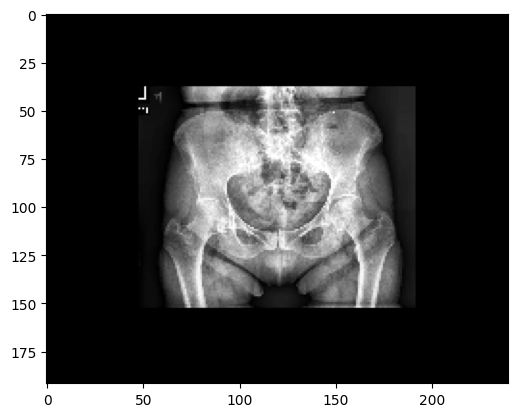

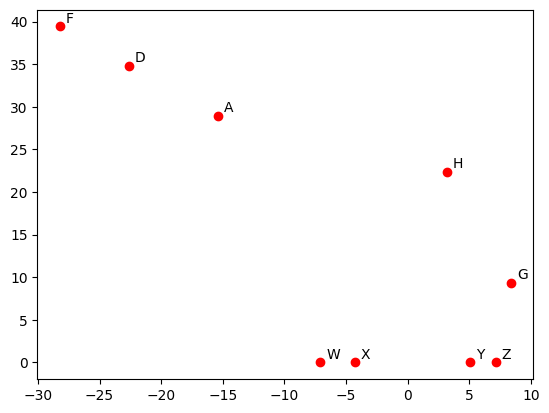

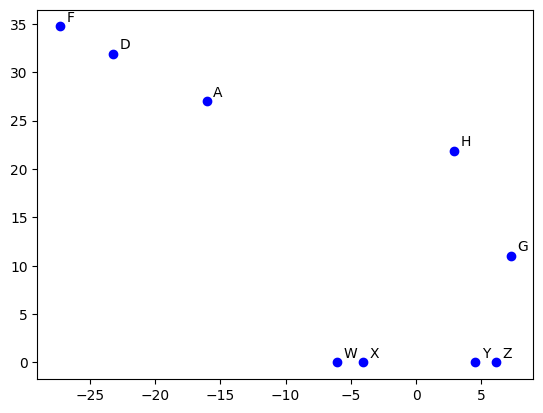

tensor([  4.8015,   3.4979,  24.2074,  31.7453,  26.1945,  49.1120,  22.8807,
         80.5289,  68.2018, 129.4763], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  3.4440,   2.6340,  20.6820,  29.5260,  27.2700,  45.9240,  22.1520,
         71.2020,  62.7960, 124.4900], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  3.4440,   2.6340,  20.6820,  29.5260,  27.2700,  45.9240,  22.1520,
         71.2020,  62.7960, 124.4900], device='mps:0')


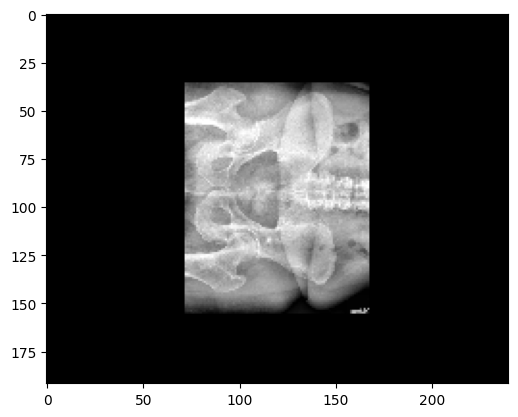

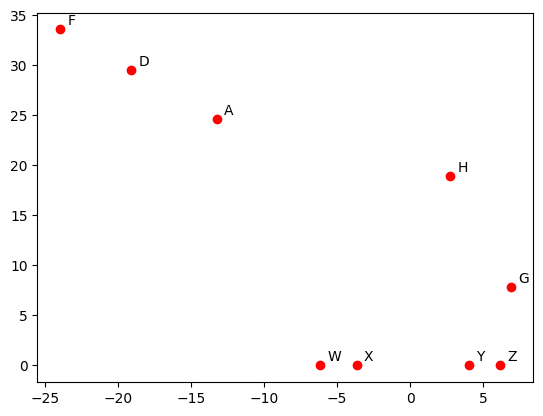

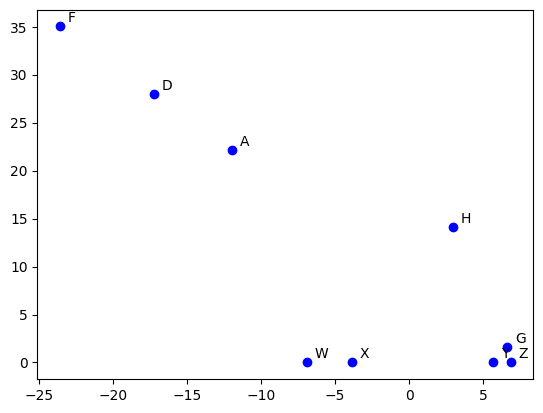

tensor([  4.2851,   3.6531,  21.0281,  25.9767,  22.5364,  41.8338,  19.8984,
         68.3795,  57.6032, 129.7917], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  5.1200,   2.0000,  23.3400,  26.7500,  20.3150,  37.6550,  19.2900,
         76.6250,  60.5050, 137.9000], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  5.1200,   2.0000,  23.3400,  26.7500,  20.3150,  37.6550,  19.2900,
         76.6250,  60.5050, 137.9000], device='mps:0')


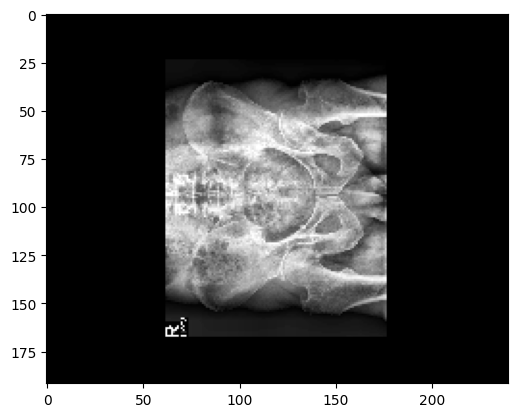

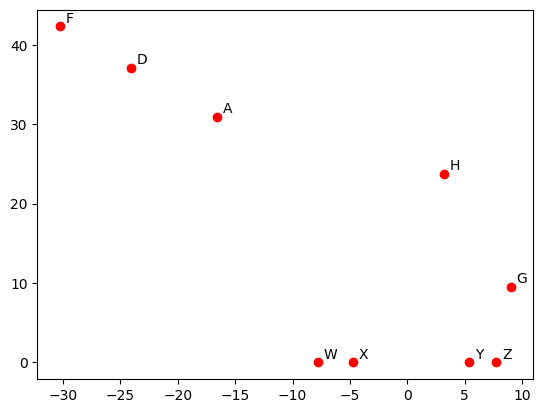

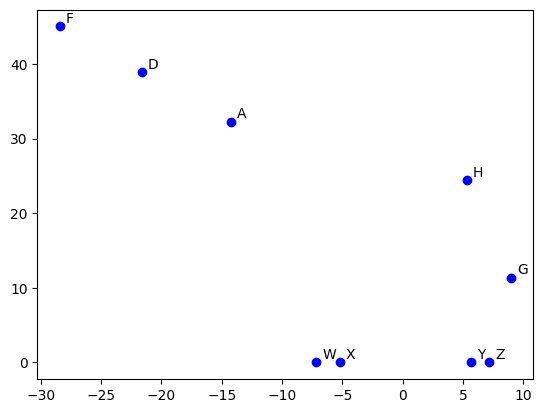

tensor([  5.0817,   4.0530,  26.3985,  33.0549,  28.2126,  52.5385,  24.2895,
         86.9649,  73.2109, 129.8251], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  3.3480,   2.6340,  24.4320,  33.8340,  24.2280,  54.8460,  24.8880,
         85.5420,  70.0320, 132.0400], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  3.3480,   2.6340,  24.4320,  33.8340,  24.2280,  54.8460,  24.8880,
         85.5420,  70.0320, 132.0400], device='mps:0')


KeyboardInterrupt: 

In [257]:
#in sample testing

model.to(device)
model.eval()

total_loss = 0
total_percent_err = torch.zeros(10).to(device)

for images, yvals, aug_scales in train_loader:
    images = images.to(device)
    yvals = yvals.to(device)
    aug_scales = aug_scales.to(device)

    model_out = model(images)
    model_coord, ab = model_to_coord(model_out, device)
    real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor, device)

    loss = lossfn(model_coord, real_coord, aug_scales)

    total_loss += loss.item()

    total_percent_err += torch.sum(torch.abs(yvals - coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)) / yvals, dim = 0)

    plt.imshow(images[0].squeeze().detach().cpu(), cmap = 'gray')
    plt.show()

    plt.scatter(model_coord[0, :, 0].detach().cpu(), model_coord[0, :, 1].detach().cpu(), c = 'r')
    for i, label in enumerate(['A', 'D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z']):
        curx, cury = model_coord[0, i]
        plt.text(curx + 0.5, cury + 0.5, label)
    plt.show()

    plt.scatter(real_coord[0, :, 0].detach().cpu(), real_coord[0, :, 1].detach().cpu(), c = 'b')
    for i, label in enumerate(['A', 'D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z']):
        curx, cury = real_coord[0, i]
        plt.text(curx + 0.5, cury + 0.5, label)
    plt.show()

    print(coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)[0])
    print(coord_to_measurements(real_coord, pix_per_mm, img_scale_factor)[0])
    print(yvals[0])

print(f'Loss (out sample): {total_loss / len(test_set)}\n')
print(f'Percent error for each measurement (out sample):')
for i in total_percent_err:
    print(f'{(i.item() / len(test_set)):.4f}', end = ' ')
print()

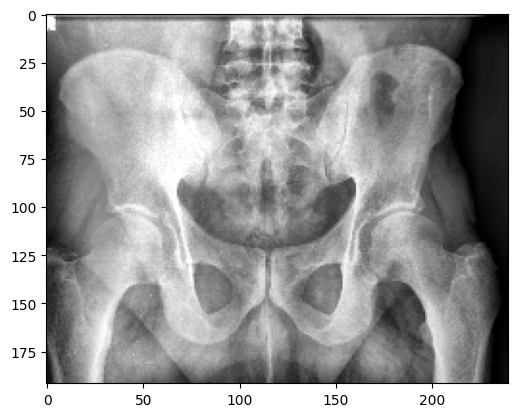

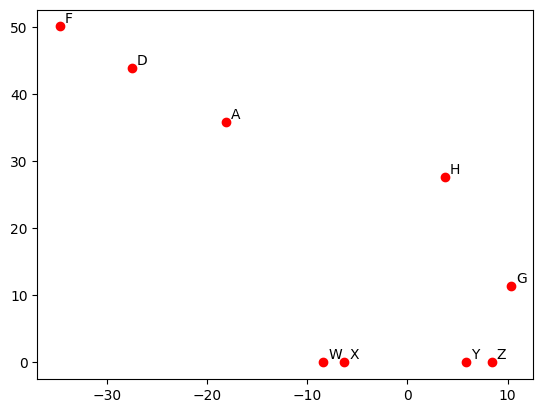

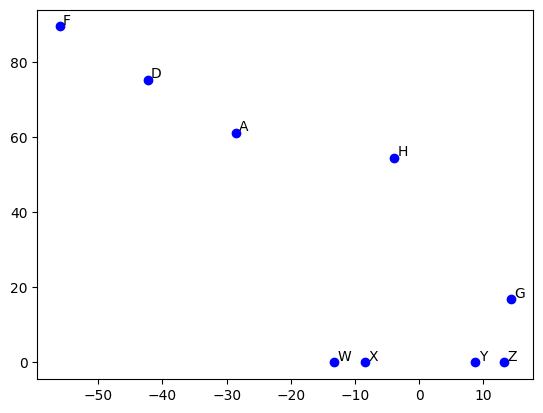

tensor([  3.6145,   4.4288,  28.5978,  42.0155,  30.8245,  60.9060,  27.4177,
        100.8531,  84.7622, 130.6671], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  8.1600,   7.6500,  45.0500,  67.0500,  48.6200, 104.0400,  44.6000,
        171.8600, 138.4200, 136.0100], device='mps:0')


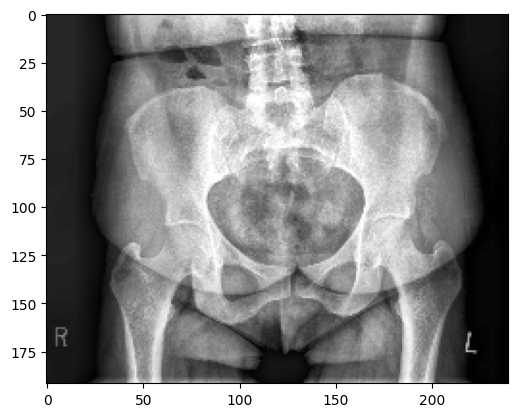

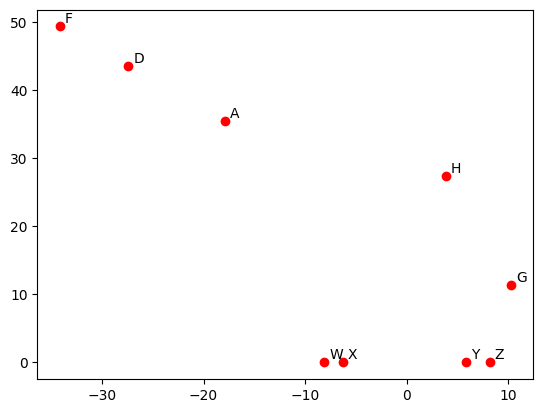

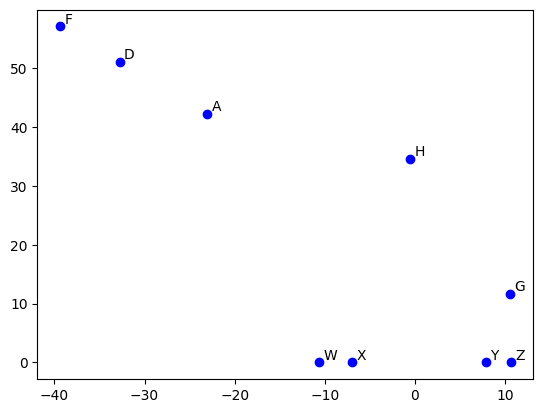

tensor([  3.1723,   4.0128,  27.7103,  42.4224,  30.4729,  60.3926,  27.2541,
         99.3303,  84.2531, 130.5830], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  6.2500,   4.7300,  36.1600,  44.6300,  39.2000,  71.8100,  32.3800,
        114.7200,  99.5100, 132.2700], device='mps:0')


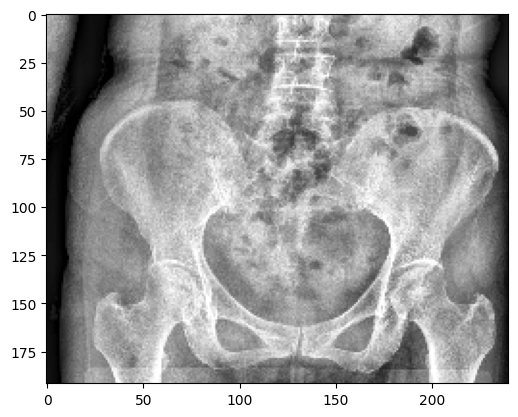

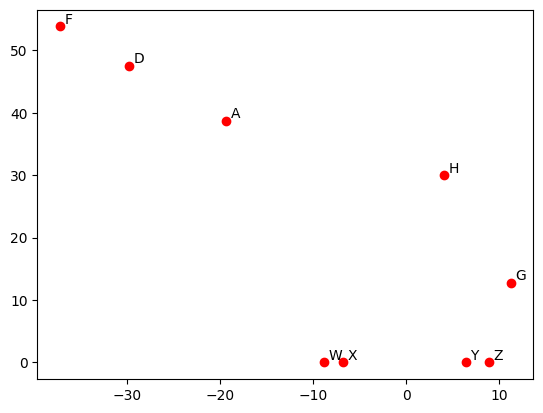

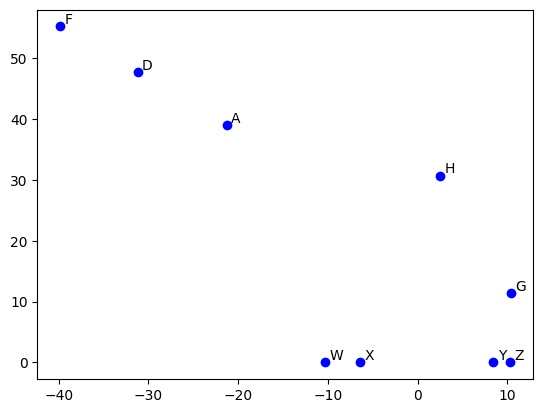

tensor([  3.4231,   4.2326,  30.1539,  46.7114,  32.8922,  65.6947,  28.8629,
        107.9936,  91.5286, 130.3462], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  6.6100,   3.2300,  35.0700,  44.9100,  36.1500,  66.3000,  31.8000,
        113.3800,  93.8500, 131.1300], device='mps:0')


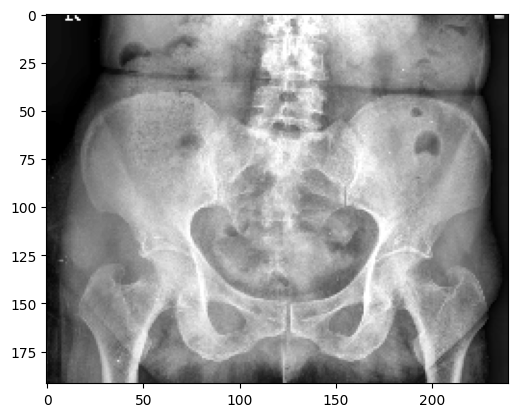

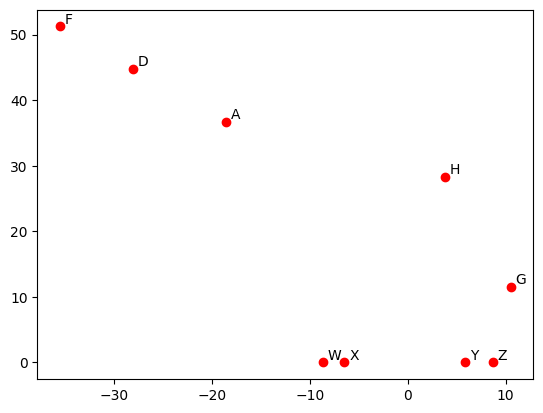

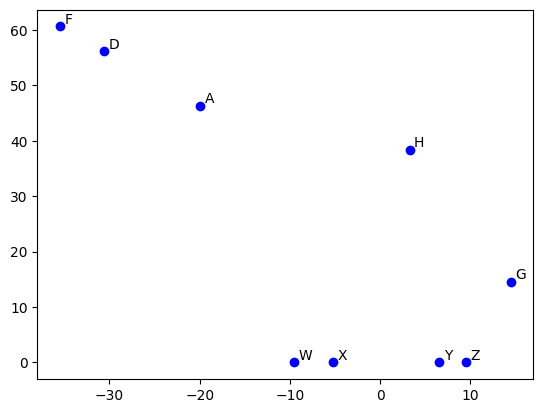

tensor([  3.7287,   4.7481,  29.4462,  42.5385,  31.6133,  62.3016,  28.1715,
        103.3682,  86.6606, 130.7988], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  7.3100,   5.1000,  32.4700,  49.2200,  33.9100,  78.7100,  33.6700,
        115.5000, 104.1900, 132.6500], device='mps:0')


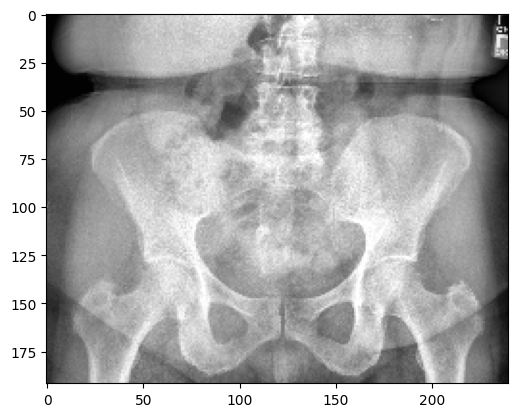

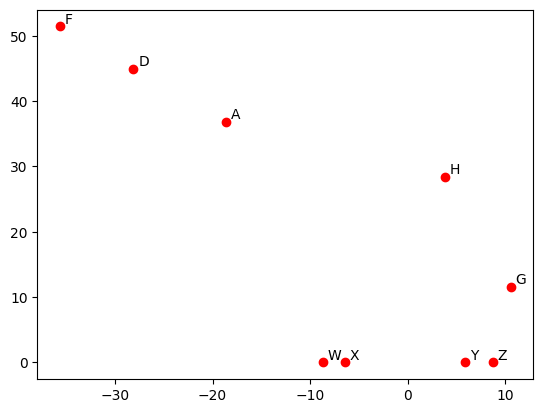

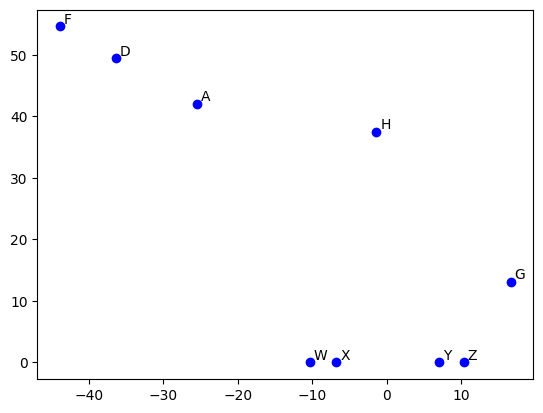

tensor([  3.8568,   4.8510,  29.6548,  42.3861,  31.7220,  62.5507,  28.0379,
        103.6808,  86.7589, 130.7518], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  6.1200,   5.6300,  35.1900,  44.5900,  43.4000,  71.4200,  33.6000,
        124.9100, 109.3100, 124.4100], device='mps:0')


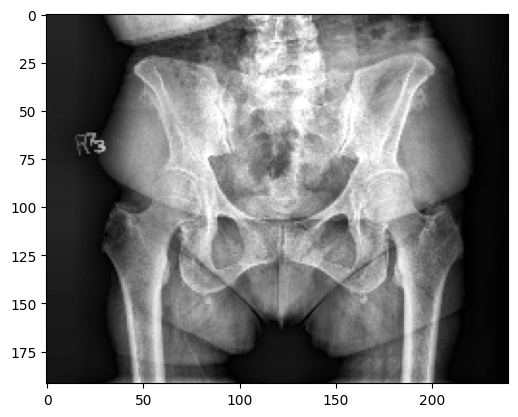

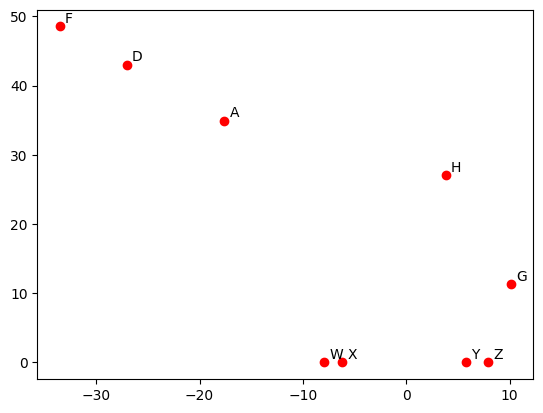

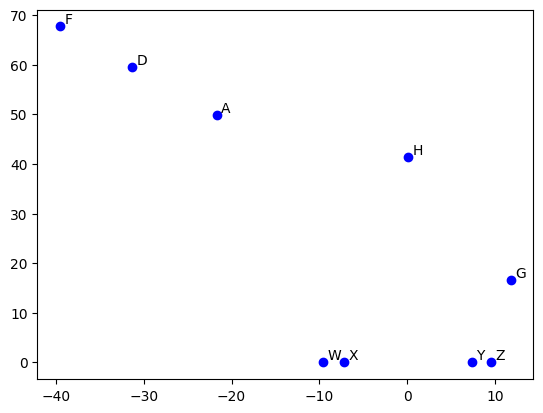

tensor([  2.9079,   3.7014,  26.9226,  42.3514,  29.9082,  59.4137,  26.8999,
         97.5303,  83.1080, 130.5051], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  4.0600,   3.7200,  32.6100,  46.2600,  36.8300,  84.8200,  31.9400,
        123.1400, 103.3800, 134.8500], device='mps:0')


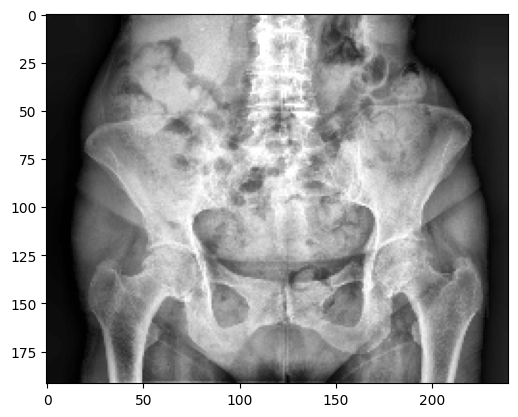

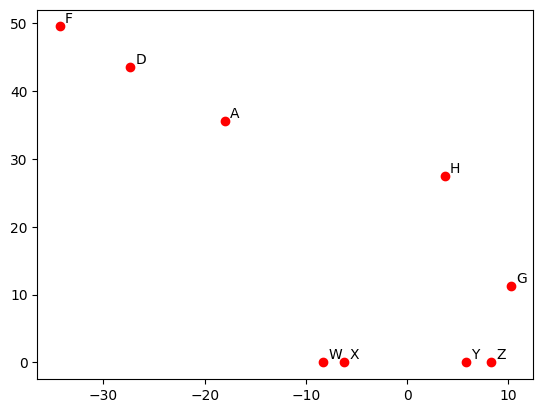

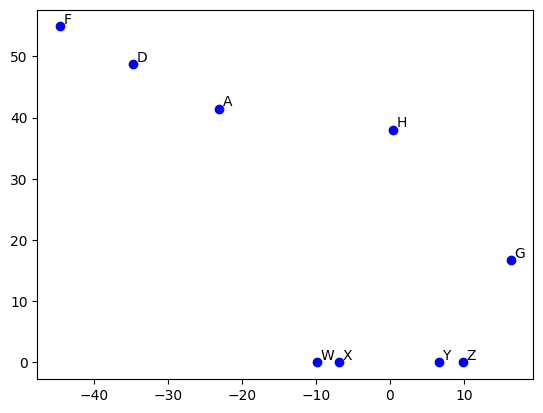

tensor([  3.5120,   4.2571,  28.1593,  41.8437,  30.5938,  60.4073,  27.1811,
         99.7124,  84.1366, 130.6071], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  5.1000,   5.6100,  33.6900,  46.5900,  39.3200,  70.3800,  32.8300,
        122.3700, 102.5100, 122.0700], device='mps:0')


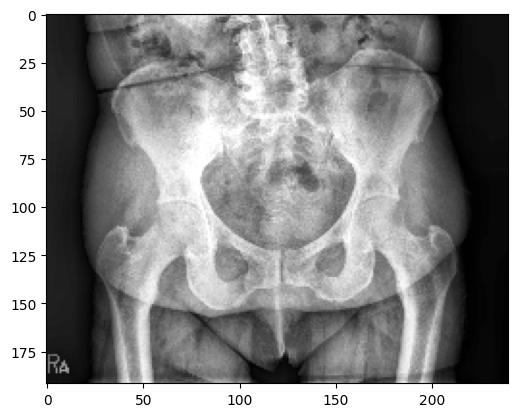

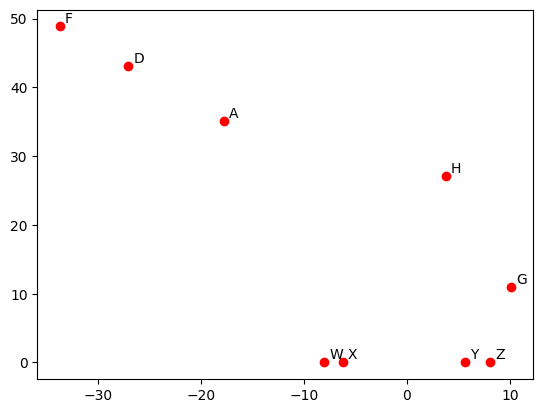

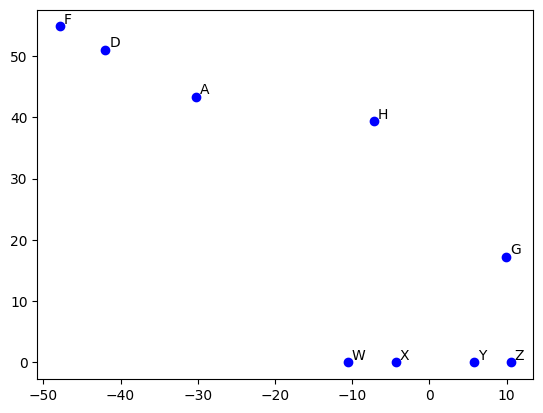

tensor([  3.1017,   4.0386,  27.3818,  41.7600,  30.1939,  59.6108,  27.3614,
         98.4389,  83.4834, 130.8498], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([ 10.4800,   8.1100,  35.8200,  47.6900,  51.3600,  73.6700,  31.4100,
        117.2200, 105.2600, 123.1000], device='mps:0')


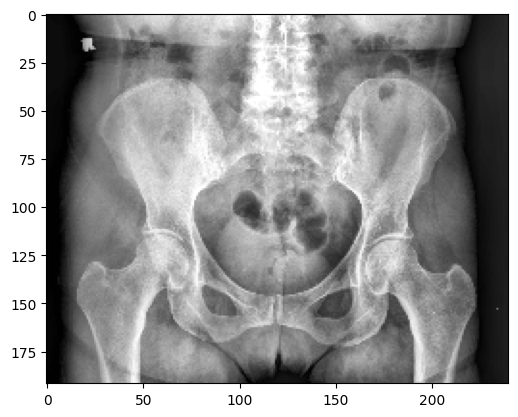

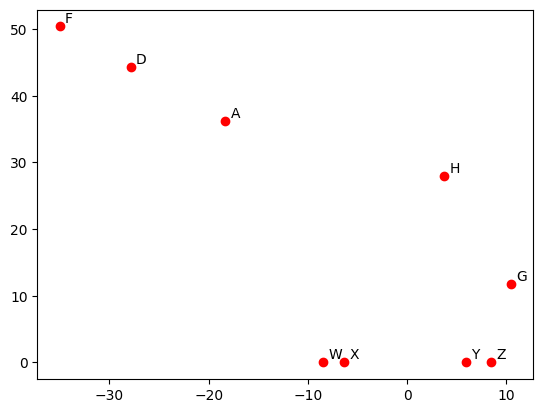

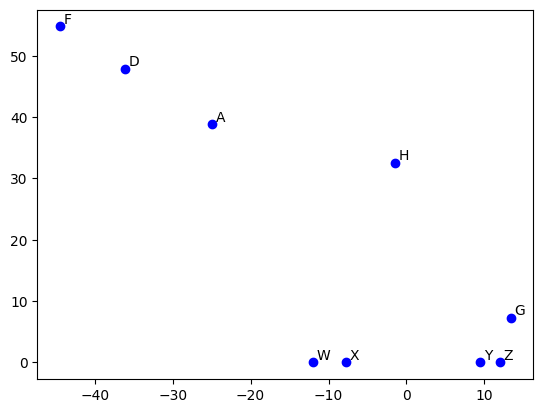

tensor([  3.6061,   4.3207,  28.7898,  42.5897,  31.1122,  61.5289,  27.2964,
        101.4333,  85.4766, 130.4082], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  7.2100,   4.3300,  40.7300,  48.7300,  42.5000,  65.9600,  34.3900,
        127.1800, 108.7600, 129.3600], device='mps:0')
Loss (out sample): 81.09850449995561

Percent error for each measurement (out sample):
0.4585 0.2430 0.2369 0.1617 0.2606 0.2333 0.2398 0.2175 0.2243 0.0307 


In [258]:
#out of sample testing

model.to(device)
model.eval()

total_loss = 0
total_percent_err = torch.zeros(10).to(device)

for images, yvals, aug_scales in test_loader:
    images = images.to(device)
    yvals = yvals.to(device)
    aug_scales = aug_scales.to(device)

    model_out = model(images)
    model_coord, ab = model_to_coord(model_out, device)
    real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor, device)

    loss = lossfn(model_coord, real_coord, aug_scales)

    total_loss += loss.item()

    total_percent_err += torch.sum(torch.abs(yvals - coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)) / yvals, dim = 0)

    plt.imshow(images[0].squeeze().detach().cpu(), cmap = 'gray')
    plt.show()

    plt.scatter(model_coord[0, :, 0].detach().cpu(), model_coord[0, :, 1].detach().cpu(), c = 'r')
    for i, label in enumerate(['A', 'D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z']):
        curx, cury = model_coord[0, i]
        plt.text(curx + 0.5, cury + 0.5, label)
    plt.show()

    plt.scatter(real_coord[0, :, 0].detach().cpu(), real_coord[0, :, 1].detach().cpu(), c = 'b')
    for i, label in enumerate(['A', 'D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z']):
        curx, cury = real_coord[0, i]
        plt.text(curx + 0.5, cury + 0.5, label)
    plt.show()

    print(coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)[0])
    print(yvals[0])

print(f'Loss (out sample): {total_loss / len(test_set)}\n')
print(f'Percent error for each measurement (out sample):')
for i in total_percent_err:
    print(f'{(i.item() / len(test_set)):.4f}', end = ' ')
print()